# Projeto do Curso — Zuber Chicago

Neste projeto, analiso dados de corridas de táxi em Chicago para identificar padrões de demanda e testar a hipótese de que a duração média das corridas do Loop para o Aeroporto Internacional O'Hare muda em sábados chuvosos.

In [ ]:
# importa as bibliotecas necessárias para análise de dados,
# visualização e teste estatístico
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# define um estilo visual para os gráficos
sns.set(style='whitegrid')

# ajusta o tamanho padrão das figuras
plt.rcParams['figure.figsize'] = (10, 6)

## Passo 4 — Análise exploratória de dados

Nesta etapa, vou trabalhar com dois arquivos:
- `project_sql_result_01.csv`: número de corridas por empresa de táxi;
- `project_sql_result_04.csv`: número médio de corridas finalizadas em cada bairro.

In [ ]:
# lê o arquivo com o número de corridas por empresa de táxi
df_companies = pd.read_csv('/datasets/project_sql_result_01.csv')

# lê o arquivo com a média de corridas finalizadas por bairro
df_neighborhoods = pd.read_csv('/datasets/project_sql_result_04.csv')

In [ ]:
# exibe as primeiras linhas do DataFrame de empresas
print('Primeiras linhas de df_companies:')
print(df_companies.head())
print()

# exibe as primeiras linhas do DataFrame de bairros
print('Primeiras linhas de df_neighborhoods:')
print(df_neighborhoods.head())

Primeiras linhas de df_companies:
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299

Primeiras linhas de df_neighborhoods:
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000


In [ ]:
# mostra informações gerais sobre o DataFrame de empresas
print('Informações sobre df_companies:')
print(df_companies.info())
print()

# mostra informações gerais sobre o DataFrame de bairros
print('Informações sobre df_neighborhoods:')
print(df_neighborhoods.info())

Informações sobre df_companies:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None

Informações sobre df_neighborhoods:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


In [ ]:
# mostra estatísticas descritivas das colunas numéricas
print('Estatísticas descritivas de df_companies:')
print(df_companies.describe())
print()

print('Estatísticas descritivas de df_neighborhoods:')
print(df_neighborhoods.describe())

Estatísticas descritivas de df_companies:
       trips_amount
count     64.000000
mean    2145.484375
std     3812.310186
min        2.000000
25%       20.750000
50%      178.500000
75%     2106.500000
max    19558.000000

Estatísticas descritivas de df_neighborhoods:
       average_trips
count      94.000000
mean      599.953728
std      1714.591098
min         1.800000
25%        14.266667
50%        52.016667
75%       298.858333
max     10727.466667


In [ ]:
# verifica valores ausentes e duplicados no DataFrame de empresas
print('Valores ausentes em df_companies:')
print(df_companies.isna().sum())
print('Duplicados em df_companies:', df_companies.duplicated().sum())
print()

# verifica valores ausentes e duplicados no DataFrame de bairros
print('Valores ausentes em df_neighborhoods:')
print(df_neighborhoods.isna().sum())
print('Duplicados em df_neighborhoods:', df_neighborhoods.duplicated().sum())

Valores ausentes em df_companies:
company_name    0
trips_amount    0
dtype: int64
Duplicados em df_companies: 0

Valores ausentes em df_neighborhoods:
dropoff_location_name    0
average_trips            0
dtype: int64
Duplicados em df_neighborhoods: 0


In [ ]:
# verifica os tipos de dados em cada DataFrame
print('Tipos de dados em df_companies:')
print(df_companies.dtypes)
print()

print('Tipos de dados em df_neighborhoods:')
print(df_neighborhoods.dtypes)

Tipos de dados em df_companies:
company_name    object
trips_amount     int64
dtype: object

Tipos de dados em df_neighborhoods:
dropoff_location_name     object
average_trips            float64
dtype: object


## Observações sobre os dados

Após a inspeção inicial, verifiquei as primeiras linhas, os tipos de dados, valores ausentes, duplicados e estatísticas descritivas.

Os campos textuais e numéricos estão em formatos adequados para a análise:
- `company_name` e `dropoff_location_name` como texto;
- `trips_amount` como valor numérico inteiro;
- `average_trips` como valor numérico.

In [ ]:
# ordena os bairros pela média de corridas em ordem decrescente
top_10_neighborhoods = df_neighborhoods.sort_values(
    by='average_trips',
    ascending=False
).head(10)

# exibe os 10 principais bairros de destino
print(top_10_neighborhoods)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


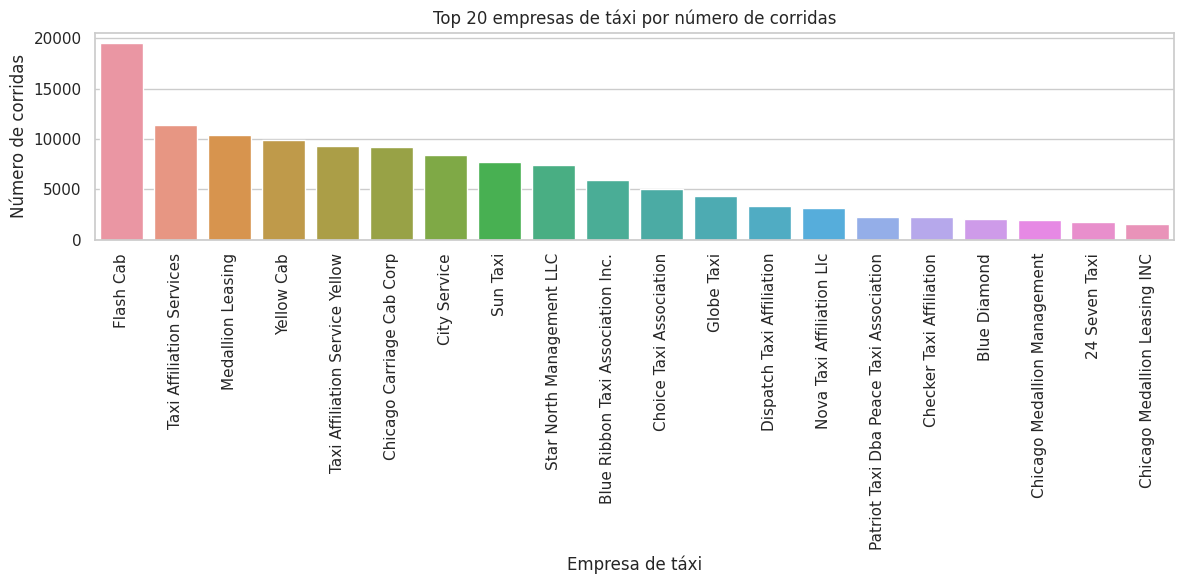

In [ ]:
# ordena as empresas pelo número de corridas
df_companies_sorted = df_companies.sort_values(by='trips_amount', ascending=False)

# cria o gráfico com as 20 empresas com mais corridas
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_companies_sorted.head(20),
    x='company_name',
    y='trips_amount'
)

# adiciona título e nomes dos eixos
plt.title('Top 20 empresas de táxi por número de corridas')
plt.xlabel('Empresa de táxi')
plt.ylabel('Número de corridas')

# rotaciona os nomes para melhorar a leitura
plt.xticks(rotation=90)

# ajusta o layout
plt.tight_layout()

# exibe o gráfico
plt.show()

## Conclusão do gráfico de empresas

O gráfico mostra que algumas empresas concentram uma quantidade muito maior de corridas do que outras.

Isso sugere que o mercado de táxi em Chicago é relativamente concentrado, com algumas empresas liderando a maior parte da demanda.

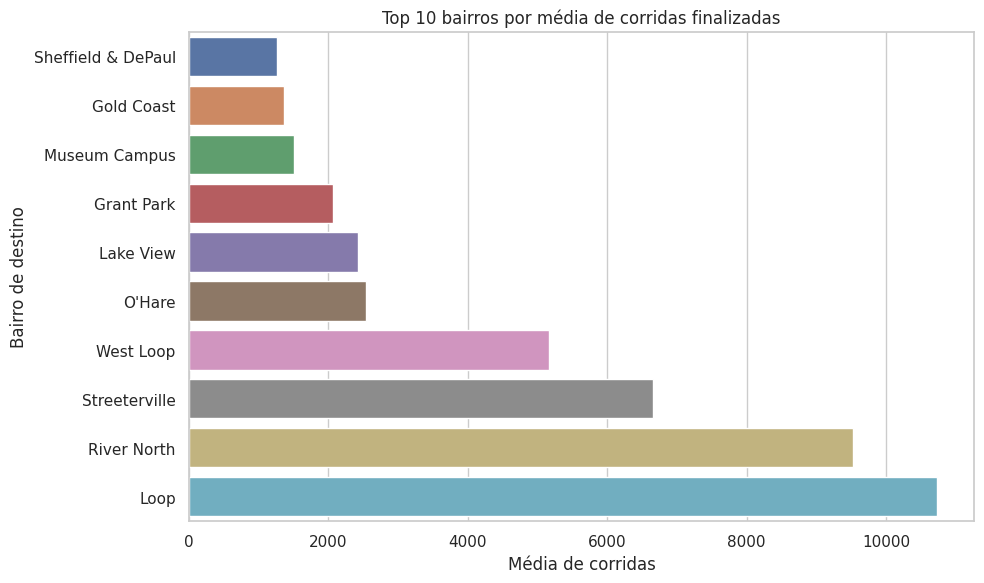

In [ ]:
# ordena os 10 principais bairros em ordem crescente para gráfico horizontal
top_10_neighborhoods_sorted = top_10_neighborhoods.sort_values(by='average_trips')

# cria o gráfico de barras horizontal
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10_neighborhoods_sorted,
    x='average_trips',
    y='dropoff_location_name'
)

# adiciona título e nomes dos eixos
plt.title('Top 10 bairros por média de corridas finalizadas')
plt.xlabel('Média de corridas')
plt.ylabel('Bairro de destino')

# ajusta o layout
plt.tight_layout()

# exibe o gráfico
plt.show()

## Conclusão do gráfico de bairros

Os bairros com maior média de corridas finalizadas se destacam como os principais destinos em Chicago.

Esses locais provavelmente concentram mais atividades comerciais, residenciais, turísticas ou conexões de transporte, o que ajuda a explicar o maior fluxo de chegadas.

## Passo 5 — Teste de hipótese

Agora vou analisar os dados das corridas do Loop para o Aeroporto Internacional O'Hare e testar a hipótese de que a duração média dessas corridas muda em sábados chuvosos.

In [ ]:
# lê o arquivo com dados das corridas do Loop para O'Hare
df_rides = pd.read_csv('/datasets/project_sql_result_07.csv')

In [ ]:
# exibe as primeiras linhas do DataFrame
print(df_rides.head())
print()

# mostra informações gerais sobre o DataFrame
print(df_rides.info())

              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None


In [ ]:
# verifica a quantidade de valores ausentes em cada coluna
print('Valores ausentes por coluna:')
print(df_rides.isna().sum())
print()

# verifica a quantidade de linhas duplicadas
print('Duplicados antes da remoção:', df_rides.duplicated().sum())

Valores ausentes por coluna:
start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64

Duplicados antes da remoção: 197


In [ ]:
# converte a coluna start_ts para o tipo datetime
df_rides['start_ts'] = pd.to_datetime(df_rides['start_ts'])

# remove linhas duplicadas para evitar distorções na análise
df_rides = df_rides.drop_duplicates()

# verifica novamente a quantidade de duplicados após a remoção
print('Duplicados após a remoção:', df_rides.duplicated().sum())
print()

# exibe os tipos de dados após os ajustes
print('Tipos de dados após ajustes:')
print(df_rides.dtypes)

Duplicados após a remoção: 0

Tipos de dados após ajustes:
start_ts              datetime64[ns]
weather_conditions            object
duration_seconds             float64
dtype: object


In [ ]:
# extrai o dia da semana da coluna start_ts
# no pandas: Monday=0, Tuesday=1, ..., Saturday=5, Sunday=6
df_rides['day_of_week'] = df_rides['start_ts'].dt.dayofweek

# verifica quais dias da semana estão presentes no conjunto de dados
print('Distribuição dos dias da semana:')
print(df_rides['day_of_week'].value_counts().sort_index())

Distribuição dos dias da semana:
5    871
Name: day_of_week, dtype: int64


## Verificação adicional dos dados

Antes do teste de hipótese, verifiquei a presença de valores ausentes, linhas duplicadas e os dias da semana representados no conjunto de dados.

As duplicatas exatas foram removidas, pois poderiam influenciar indevidamente a média da duração das corridas e o resultado do teste estatístico.

Também confirmei os dias presentes na coluna `start_ts`. Como o arquivo foi gerado a partir de uma consulta SQL filtrada para sábados, essa etapa serve para validar a consistência dos dados antes da análise.

In [ ]:
# conta o número de corridas por condição climática
print('Quantidade de corridas por condição climática:')
print(df_rides['weather_conditions'].value_counts())
print()

# mostra estatísticas descritivas da duração das corridas por condição climática
print('Estatísticas da duração por condição climática:')
print(df_rides.groupby('weather_conditions')['duration_seconds'].describe())

Quantidade de corridas por condição climática:
Good    723
Bad     148
Name: weather_conditions, dtype: int64

Estatísticas da duração por condição climática:
                    count         mean         std    min     25%     50%  \
weather_conditions                                                          
Bad                 148.0  2409.229730  751.544705  480.0  1746.0  2463.5   
Good                723.0  2032.253112  773.444860    0.0  1435.5  1883.0   

                       75%     max  
weather_conditions                  
Bad                 2940.0  4980.0  
Good                2491.5  7440.0  


## Formulação das hipóteses

### Hipótese nula (H0)
A duração média das corridas do Loop para o Aeroporto Internacional O'Hare é a mesma em sábados com clima ruim e em sábados com clima bom.

### Hipótese alternativa (H1)
A duração média das corridas do Loop para o Aeroporto Internacional O'Hare é diferente em sábados com clima ruim e em sábados com clima bom.

A hipótese alternativa é bicaudal, porque queremos verificar se a duração média das corridas muda, sem assumir antecipadamente se ela aumenta ou diminui.

In [ ]:
# separa as durações das corridas em dois grupos:
# clima ruim (Bad) e clima bom (Good)
bad_weather = df_rides[df_rides['weather_conditions'] == 'Bad']['duration_seconds']
good_weather = df_rides[df_rides['weather_conditions'] == 'Good']['duration_seconds']

# define o nível de significância
alpha = 0.05

In [ ]:
# aplica o teste t para duas amostras independentes
# equal_var=False é usado porque não assumimos variâncias iguais entre os grupos
results = stats.ttest_ind(bad_weather, good_weather, equal_var=False)

# exibe o valor-p
print('p-value:', results.pvalue)

p-value: 9.126383933880083e-08


In [ ]:
# compara o valor-p com o nível de significância
if results.pvalue < alpha:
    print('Rejeitamos a hipótese nula')
    print('Há evidências estatísticas suficientes para afirmar que a duração média das corridas muda em sábados chuvosos.')
else:
    print('Não rejeitamos a hipótese nula')
    print('Não há evidências estatísticas suficientes para afirmar que a duração média das corridas muda em sábados chuvosos.')

Rejeitamos a hipótese nula
Há evidências estatísticas suficientes para afirmar que a duração média das corridas muda em sábados chuvosos.


## Interpretação do teste

Foi utilizado o teste t para duas amostras independentes, pois o objetivo é comparar a média da duração das corridas entre dois grupos distintos:
- corridas com clima ruim (`Bad`);
- corridas com clima bom (`Good`).

O nível de significância adotado foi de 5%.

Se o valor-p for menor que 0.05, rejeitamos a hipótese nula e concluímos que há evidências estatísticas de que a duração média das corridas muda em sábados chuvosos.

Se o valor-p for maior ou igual a 0.05, não rejeitamos a hipótese nula e concluímos que não há evidências estatísticas suficientes para afirmar que a duração média muda.

# Conclusão final

Neste projeto, analisei dados de corridas de táxi em Chicago para identificar padrões de demanda e avaliar o impacto do clima na duração das viagens.

Na análise exploratória, observei que algumas empresas concentram a maior parte das corridas, enquanto certos bairros se destacam como os principais destinos.

Na etapa de teste de hipótese, comparei a duração média das corridas do Loop para o Aeroporto Internacional O'Hare em sábados com clima ruim e com clima bom, utilizando um teste t para duas amostras independentes.

Com base no valor-p obtido, rejeitamos a hipótese nula (H0). Assim, há evidências estatísticas suficientes para afirmar que a duração média dessas corridas muda em sábados chuvosos.